In [ ]:
import torch

In [ ]:
model_info = {
    # 'MyNetwork':      {'val_acc': 0, 'flops': 0},
    'efficientnet_b0': {'val_acc': 33.01, 'flops': 0},
    'efficientnet_b1': {'val_acc': 29.81, 'flops': 0},
    'efficientnet_b2': {'val_acc': 33.49, 'flops': 0},
    'efficientnet_b3': {'val_acc': 29.71, 'flops': 0},
    'efficientnet_b4': {'val_acc': 29.54, 'flops': 0},
    'efficientnet_b5': {'val_acc': 24.02, 'flops': 0},
    'efficientnet_b6': {'val_acc': 22.5, 'flops': 0},
    'efficientnet_b7': {'val_acc': 22.97, 'flops': 0},
    'resnet18':        {'val_acc': 41.62, 'flops': 0},
    'resnet50':        {'val_acc': 39.31, 'flops': 0},
    'resnet101':       {'val_acc': 39.1, 'flops': 0},
    # 'swin_t':          {'val_acc': 0, 'flops': 0},
    # 'swin_s':          {'val_acc': 0, 'flops': 0},
    # 'swin_b':          {'val_acc': 0, 'flops': 0},
}


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.alexnet import AlexNet


In [5]:
# [TODO: Optional] Rewrite this class if you want
class MyNetwork(AlexNet):
    def __init__(self, num_classes: int = 1000, dropout: float = 0.5) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = MyNetwork(num_classes=200, dropout=0.5)
print(f"Paramters: {sum(p.numel() for p in model.parameters())}")
print(f"Flops: {sum(p.numel() for p in model.parameters()) * 2}")  # Rough estimate

Paramters: 57823240
Flops: 115646480


In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out += x
        return self.relu(out)

# AlexNet-based model for smaller inputs
class MyNetwork(nn.Module):
    def __init__(self, num_classes=1000, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=2, padding=2),  # ↓ feature size 줄이기 완화
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # ↓ downsample 약하게

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(192),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(384),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(256),

            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((3, 3))  # 6x6 → 3x3

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 3 * 3, 1024),  # feature map이 작아졌으니 linear도 축소
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


model = MyNetwork(num_classes=200, dropout=0.5)
print(f"Paramters: {sum(p.numel() for p in model.parameters())}")
print(f"Flops: {sum(p.numel() for p in model.parameters()) * 2}")  # Rough estimate

Paramters: 5745416
Flops: 11490832


In [25]:
from torchvision.models.resnet import resnet18
model = resnet18(num_classes=200)
print(f"Paramters: {sum(p.numel() for p in model.parameters())}")

Paramters: 11279112


In [16]:
model_info = {
    # 'MyNetwork':      {'val_acc': 0, 'flops': 0},
    'efficientnet_b0': {'val_acc': 33.01, 'flops': 0},
    'efficientnet_b1': {'val_acc': 29.81, 'flops': 0},
    'efficientnet_b2': {'val_acc': 33.49, 'flops': 0},
    'efficientnet_b3': {'val_acc': 29.71, 'flops': 0},
    'efficientnet_b4': {'val_acc': 29.54, 'flops': 0},
    'efficientnet_b5': {'val_acc': 24.02, 'flops': 0},
    'efficientnet_b6': {'val_acc': 22.5, 'flops': 0},
    'efficientnet_b7': {'val_acc': 22.97, 'flops': 0},
    'resnet18':        {'val_acc': 41.62, 'flops': 0},
    'resnet50':        {'val_acc': 39.31, 'flops': 0},
    'resnet101':       {'val_acc': 39.1, 'flops': 0},
    # 'swin_t':          {'val_acc': 0, 'flops': 0},
    # 'swin_s':          {'val_acc': 0, 'flops': 0},
    # 'swin_b':          {'val_acc': 0, 'flops': 0},
}


In [17]:
import torch
import torch.nn as nn
import timm
from torchvision import models
from torchvision.models import resnet18, resnet50
from torchvision.models.swin_transformer import swin_t, swin_s, swin_b
from torch.utils.flop_counter import FlopCounterMode


def count_flops(model_name: str, input_tensor: torch.Tensor, num_classes: int = 200):
    # 모델 초기화
    if 'resnet' in model_name:
        model = torch.hub.load('pytorch/vision:v0.10.0', model_name, pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif 'efficientnet' in model_name:
        model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    elif 'swin' in model_name:
        if 't' in model_name:
            model = swin_t(weights=None)
        elif 's' in model_name:
            model = swin_s(weights=None)
        elif 'b' in model_name:
            model = swin_b(weights=None)
        else:
            raise ValueError(f"Unknown Swin model: {model_name}")
        model.head = nn.Linear(model.head.in_features, num_classes)
    else:
        models_list = timm.list_models()
        assert model_name in models_list, f'Unknown model name: {model_name}. Choose from: {", ".join(models_list)}'
        model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)

    model.eval()

    # FLOPs 계산
    with FlopCounterMode(model) as fcm:
        _ = model(input_tensor)
        flops = fcm.get_total_flops()

    return flops

for k, v in model_info.items():
    model_name = k
    input_tensor = torch.randn(1, 3, 64, 64)  # Example input tensor
    flops = count_flops(model_name, input_tensor)
    model_info[k]['flops'] = flops
    print(f"{model_name}: {flops / 1e9:.2f} GFLOPs")

Module                          FLOP    % Total
------------------------  ----------  ---------
EfficientNet              64445.184K    100.00%
 - aten.convolution       63933.184K     99.21%
 - aten.addmm               512.000K      0.79%
 EfficientNet.conv_stem    1769.472K      2.75%
  - aten.convolution       1769.472K      2.75%
 EfficientNet.blocks      58886.912K     91.38%
  - aten.convolution      58886.912K     91.38%
 EfficientNet.conv_head    3276.800K      5.08%
  - aten.convolution       3276.800K      5.08%
 EfficientNet.classifier    512.000K      0.79%
  - aten.addmm              512.000K      0.79%
efficientnet_b0: 0.06 GFLOPs
Module                          FLOP    % Total
------------------------  ----------  ---------
EfficientNet              95343.360K    100.00%
 - aten.convolution       94831.360K     99.46%
 - aten.addmm               512.000K      0.54%
 EfficientNet.conv_stem    1769.472K      1.86%
  - aten.convolution       1769.472K      1.86%
 EfficientN

Using cache found in /home/work/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Using cache found in /home/work/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equ

Module                    FLOP    % Total
--------------------  --------  ---------
ResNet                668.107M    100.00%
 - aten.convolution   667.288M     99.88%
 - aten.addmm           0.819M      0.12%
 ResNet.conv1          19.268M      2.88%
  - aten.convolution   19.268M      2.88%
 ResNet.layer1        109.052M     16.32%
  - aten.convolution  109.052M     16.32%
 ResNet.layer2        167.772M     25.11%
  - aten.convolution  167.772M     25.11%
 ResNet.layer3        239.075M     35.78%
  - aten.convolution  239.075M     35.78%
 ResNet.layer4        132.121M     19.78%
  - aten.convolution  132.121M     19.78%
 ResNet.fc              0.819M      0.12%
  - aten.addmm          0.819M      0.12%
resnet50: 0.67 GFLOPs


Using cache found in /home/work/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Module                     FLOP    % Total
--------------------  ---------  ---------
ResNet                1274.184M    100.00%
 - aten.convolution   1273.364M     99.94%
 - aten.addmm            0.819M      0.06%
 ResNet.conv1           19.268M      1.51%
  - aten.convolution    19.268M      1.51%
 ResNet.layer1         109.052M      8.56%
  - aten.convolution   109.052M      8.56%
 ResNet.layer2         167.772M     13.17%
  - aten.convolution   167.772M     13.17%
 ResNet.layer3         845.152M     66.33%
  - aten.convolution   845.152M     66.33%
 ResNet.layer4         132.121M     10.37%
  - aten.convolution   132.121M     10.37%
 ResNet.fc               0.819M      0.06%
  - aten.addmm           0.819M      0.06%
resnet101: 1.27 GFLOPs


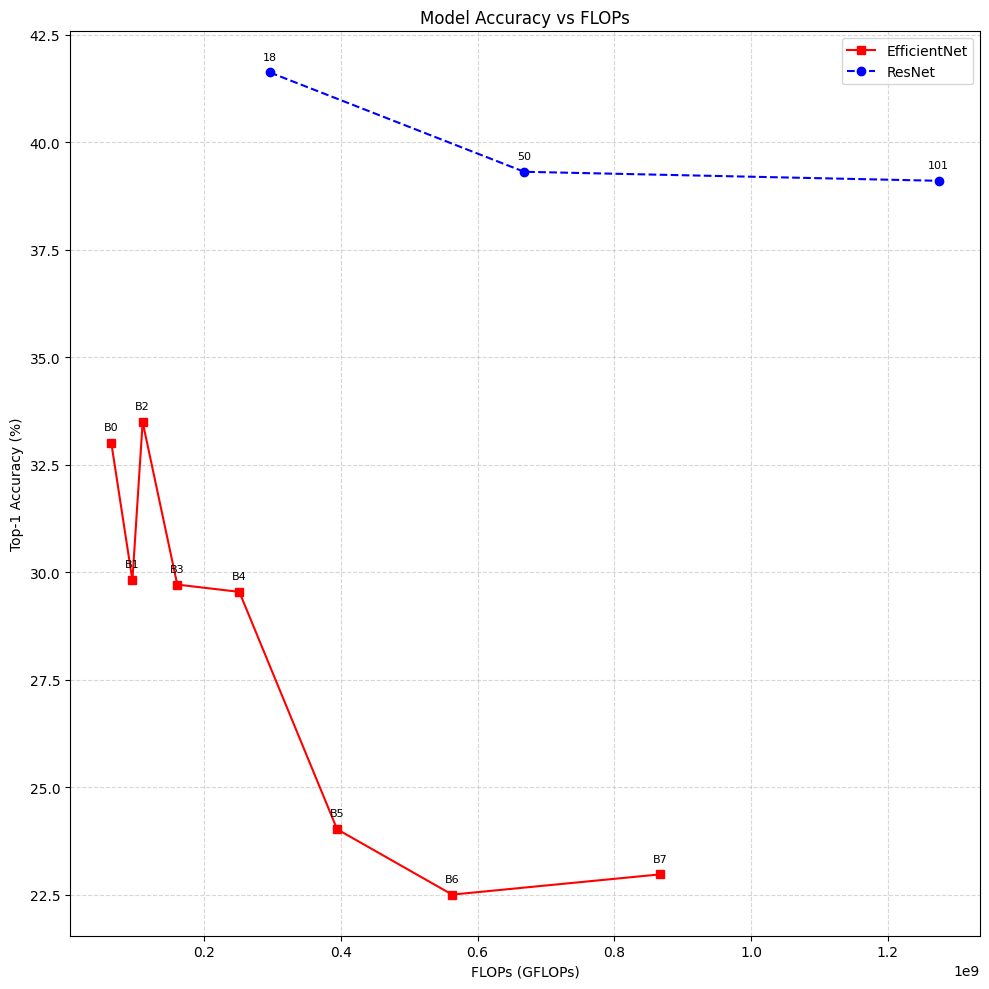

In [19]:
import matplotlib.pyplot as plt

def draw_graph(model_info):
    # 분리해서 그리기 위해 모델 계열별로 나눔
    efficientnet_series = {}
    resnet_series = {}

    for name, stats in model_info.items():
        if name.startswith('efficientnet'):
            efficientnet_series[name] = stats
        elif name.startswith('resnet'):
            resnet_series[name] = stats

    def sorted_by_flops(series):
        return sorted(series.items(), key=lambda x: x[1]['flops'])

    plt.figure(figsize=(10, 10))

    # EfficientNet 시리즈 (빨간색 라인 + 정사각형 마커)
    eff_x = [v['flops'] for k, v in sorted_by_flops(efficientnet_series)]
    eff_y = [v['val_acc'] for k, v in sorted_by_flops(efficientnet_series)]
    eff_labels = [k.split('_')[-1].upper() for k, _ in sorted_by_flops(efficientnet_series)]
    plt.plot(eff_x, eff_y, color='red', marker='s', label='EfficientNet')

    for x, y, label in zip(eff_x, eff_y, eff_labels):
        plt.text(x, y + 0.3, label, fontsize=8, ha='center')

    # ResNet 시리즈 (파란색 점선 + 동그라미 마커)
    res_x = [v['flops'] for k, v in sorted_by_flops(resnet_series)]
    res_y = [v['val_acc'] for k, v in sorted_by_flops(resnet_series)]
    res_labels = [k.replace('resnet', '') for k, _ in sorted_by_flops(resnet_series)]
    plt.plot(res_x, res_y, color='blue', linestyle='--', marker='o', label='ResNet')

    for x, y, label in zip(res_x, res_y, res_labels):
        plt.text(x, y + 0.3, label, fontsize=8, ha='center')

    plt.title('Model Accuracy vs FLOPs')
    plt.xlabel('FLOPs (GFLOPs)')
    plt.ylabel('Top-1 Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

draw_graph(model_info)

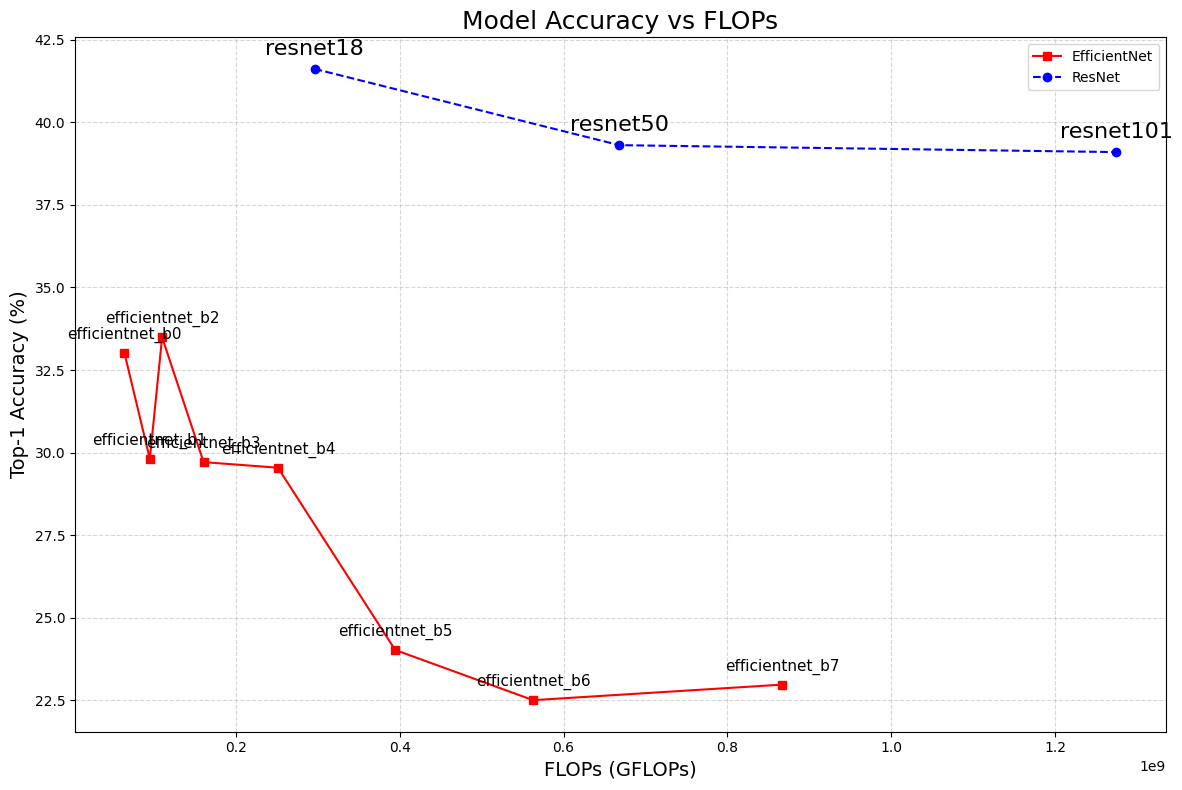

In [24]:
import matplotlib.pyplot as plt

def draw_graph(model_info):
    efficientnet_series = {}
    resnet_series = {}

    for name, stats in model_info.items():
        if name.startswith('efficientnet'):
            efficientnet_series[name] = stats
        elif name.startswith('resnet'):
            resnet_series[name] = stats

    def sorted_by_flops(series):
        return sorted(series.items(), key=lambda x: x[1]['flops'])

    plt.figure(figsize=(12, 8))

    # EfficientNet
    eff_sorted = sorted_by_flops(efficientnet_series)
    eff_x = [v['flops'] for _, v in eff_sorted]
    eff_y = [v['val_acc'] for _, v in eff_sorted]
    eff_labels = [k for k, _ in eff_sorted]
    plt.plot(eff_x, eff_y, color='red', marker='s', label='EfficientNet')

    for x, y, label in zip(eff_x, eff_y, eff_labels):
        plt.text(x, y + 0.3, label, fontsize=11, ha='center', va='bottom')

    # ResNet
    res_sorted = sorted_by_flops(resnet_series)
    res_x = [v['flops'] for _, v in res_sorted]
    res_y = [v['val_acc'] for _, v in res_sorted]
    res_labels = [k for k, _ in res_sorted]
    plt.plot(res_x, res_y, color='blue', linestyle='--', marker='o', label='ResNet')

    for x, y, label in zip(res_x, res_y, res_labels):
        plt.text(x, y + 0.3, label, fontsize=16, ha='center', va='bottom')

    plt.title('Model Accuracy vs FLOPs', fontsize=18)
    plt.xlabel('FLOPs (GFLOPs)', fontsize=14)
    plt.ylabel('Top-1 Accuracy (%)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
draw_graph(model_info)